In [1]:
get_ipython().run_line_magic('matplotlib', 'inline')
import sys, platform, json, importlib.metadata, torch
assert not torch.cuda.is_available(), 'CPU teaching lane unexpectedly sees CUDA'
identity = dict(executable=sys.executable, prefix=sys.prefix, python=platform.python_version(), platform=platform.platform(), cuda_available=torch.cuda.is_available(), torch_cuda_build=torch.version.cuda, packages={name:importlib.metadata.version(name) for name in ['torch','numpy','matplotlib','nbformat','nbclient','ipykernel','transformers','tokenizers','peft']})
print('__DONGXI_KERNEL_IDENTITY__:' + json.dumps(identity, sort_keys=True))

__DONGXI_KERNEL_IDENTITY__:{"cuda_available": false, "executable": "/tmp/dongxi-course-reproduction.ZfVaEu/venv/bin/python", "packages": {"ipykernel": "7.4.0", "matplotlib": "3.10.8", "nbclient": "0.11.0", "nbformat": "5.11.1", "numpy": "2.5.3", "peft": "0.20.0", "tokenizers": "0.23.2", "torch": "2.14.1+cpu", "transformers": "5.18.0"}, "platform": "Linux-6.17.0-1031-nvidia-aarch64-with-glibc2.39", "prefix": "/tmp/dongxi-course-reproduction.ZfVaEu/venv", "python": "3.12.14", "torch_cuda_build": null}


# Reward models: learn quality or a shortcut?

Day 16 · Chapter 10. CPU, authored synthetic data, no downloads. Predict before each reference, change one declared variable, and interpret the result. Code is complete so the notebook runs from beginning to end. Completing its execution is material verification, not an assessment of learner mastery.

[Canonical chapter](../../book/chapters/10-preferences-and-reward-models.md)


In [2]:
from pathlib import Path
import sys
root = Path.cwd().resolve()
while not (root / "src" / "dongxi_llms").is_dir():
    if root.parent == root:
        raise RuntimeError("Open this notebook within the Dongxi_LLMs repository")
    root = root.parent
sys.path.insert(0, str(root / "src"))
import torch
import matplotlib.pyplot as plt
torch.set_num_threads(1)
plt.rcParams.update({"figure.facecolor": "white", "axes.facecolor": "white",
                     "font.family": "DejaVu Sans", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 11})
blue, orange, green = "#356a9b", "#b97139", "#3d8268"



## Pre-run prediction

Labels depend on substantive quality. In one training arm, length and polished format are almost the same as quality. In the other they vary independently. Predict both arms' training behavior and their response to a worse-but-longer answer.

The features are synthetic coordinates; the diagram does not assert that a neural model exposes human-readable quality features.


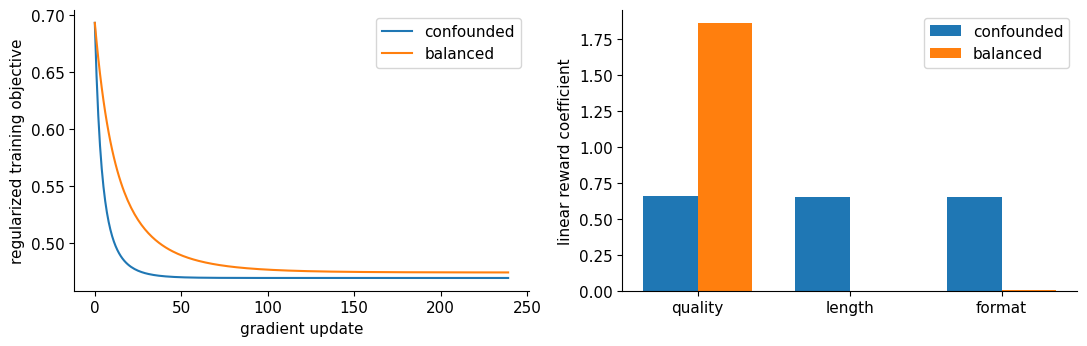

{'confounded': {'weights': [0.6558978716018705, 0.6493007859212913, 0.6511022052745514], 'train_nll': 0.46664298668247095, 'validation_nll': 0.6529132986905999, 'adversarial_first_win_probability': 0.9625042577040702, 'expected_brier': 0.22844367204231497, 'ece': 0.06335570137798231}, 'balanced': {'weights': [1.8553880930285784, -1.7845670585156363e-05, 0.004854212186455453], 'train_nll': 0.4671653057954894, 'validation_nll': 0.48099465814594927, 'adversarial_first_win_probability': 0.13694736872867358, 'expected_brier': 0.158445632424157, 'ece': 0.011335048328973083}}


In [3]:
from dongxi_llms.reward_model_lab import reward_comparison,preference_fixture
results = reward_comparison()
fig, axes = plt.subplots(1,2,figsize=(11,3.6))
for name, result in results.items():
    axes[0].plot(result["history"],label=name)
x = torch.arange(3).numpy()
for offset,(name,result) in zip((-.18,.18),results.items()):
    axes[1].bar(x+offset,result["weights"],width=.36,label=name)
axes[0].set(xlabel="gradient update",ylabel="regularized training objective");axes[0].legend()
axes[1].set_xticks(x,["quality","length","format"]);axes[1].set_ylabel("linear reward coefficient");axes[1].legend()
plt.tight_layout();plt.show()
print({name:{k:v for k,v in r.items() if k not in ("history","bins")} for name,r in results.items()})


![Saved reference plot for 01 reward model bias audit, figure 1](../figures/chapter-10/day-16-01_reward_model_bias_audit-01.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** highly correlated features let the confounded arm spread credit across nuisance coordinates. The balanced distribution supplies contrasts that identify the intended signal. Good training loss is insufficient to detect the shortcut.

## Exercise 2: challenge the scores

Predict which model rewards a substantively worse first answer with length and format differences +3. Change one nuisance coordinate at a time. The following plot uses the fitted weights, not an imagined failure.


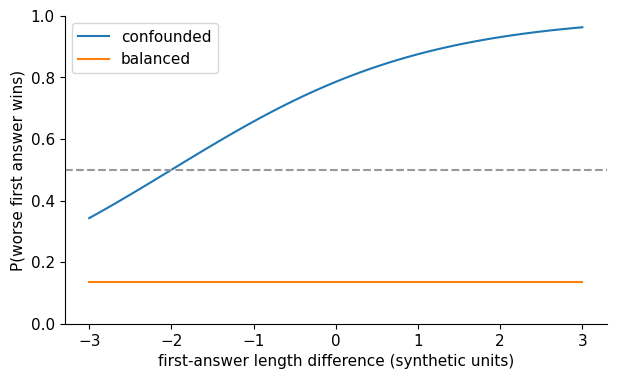

In [4]:
length = torch.linspace(-3,3,100,dtype=torch.float64)
format_difference = 3.
features = torch.stack((-torch.ones_like(length),length,
                         torch.full_like(length,format_difference)),1)
fig,ax=plt.subplots(figsize=(7,4))
for name,result in results.items():
    weight=torch.tensor(result["weights"],dtype=torch.float64)
    ax.plot(length,(features@weight).sigmoid(),label=name)
ax.axhline(.5,color=".6",ls="--")
ax.set(xlabel="first-answer length difference (synthetic units)",
       ylabel="P(worse first answer wins)",ylim=(0,1));ax.legend();plt.show()


![Saved reference plot for 01 reward model bias audit, figure 2](../figures/chapter-10/day-16-01_reward_model_bias_audit-02.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Read the figure:** crossing .5 means the model reverses the intended quality comparison. This varies length while holding quality −1 and format +3. Change the held-fixed values and regenerate the plot.

## Exercise 3: independent validation

Compare training NLL with NLL on independently varied features. Explain which distribution each metric describes.


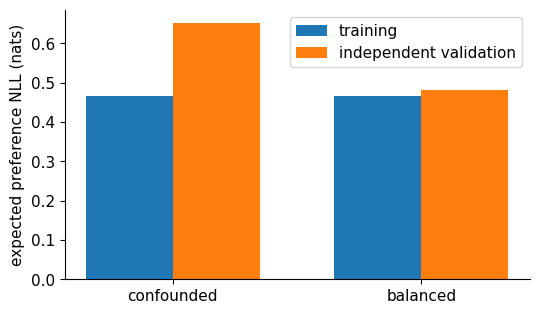

No model-scale reward or human annotation was used.


In [5]:
fig,ax=plt.subplots(figsize=(6,3.5))
names=list(results)
ax.bar([0,1],[results[n]["train_nll"] for n in names],width=.35,label="training")
ax.bar([.35,1.35],[results[n]["validation_nll"] for n in names],width=.35,label="independent validation")
ax.set_xticks([.175,1.175],names);ax.set_ylabel("expected preference NLL (nats)");ax.legend();plt.show()
print("No model-scale reward or human annotation was used.")


![Saved reference plot for 01 reward model bias audit, figure 3](../figures/chapter-10/day-16-01_reward_model_bias_audit-03.png)

Saved reference output from the verified CPU run. Run the preceding cell to regenerate the current experiment; this image does not change when parameters are edited.


**Solution:** training fit measures agreement in the correlated population; the independent validation distribution challenges that correlation. Feature balancing is an intervention in this known simulator, not a universal recipe guaranteeing reward reliability. The separate adversary is a prespecified diagnostic case, not a test set selected after the result.

**Evidence boundary:** linear synthetic outcome scores do not establish process-reward quality, neural representation learning, or robustness to every policy-selected response.
